In [1]:
import numpy as np
from monodromy.haar import expected_cost
from monodromy.render import _plot_coverage_set
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm
from weylchamber import c1c2c3

from gulps.gulps_decomposer import GulpsDecomposer
from gulps.synthesis_pass import GulpsDecompositionPass
from gulps.utils.invariants import GateInvariants
from gulps.utils.isa import expected_haar_and_depth
from gulps.utils.visualize import render_path

# from gulps.synthesis_plugin import GulpsSynthesisPlugin

In [2]:
from gulps.utils.logging_config import logger

logger.setLevel("INFO")
# logger.setLevel("DEBUG")

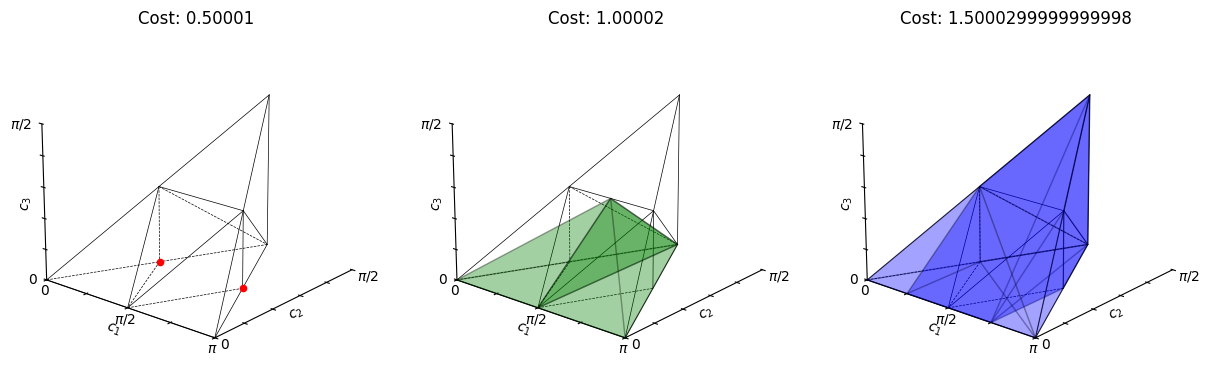

(np.float64(1.1049634169842018), np.float64(2.209882636315678))


In [3]:
def fsim(theta, phi):
    _fsim = QuantumCircuit(2, name="fsim")
    _fsim.append(XXPlusYYGate(2 * theta), [0, 1])
    _fsim.cp(phi, 0, 1)
    return _fsim.to_gate()


# comment out what you don't want or add your own
isa = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (iSwapGate(), 1.0, "iswap"),
    (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    # (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    # (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (SwapGate(), 0.0, "swap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)
if hasattr(decomposer.isa, "coverage_set"):
    _plot_coverage_set(decomposer.isa.coverage_set)
    print(expected_haar_and_depth(decomposer.isa.coverage_set))

In [5]:
logger.setLevel("INFO")
N = 100
fidelities = []

for idx in tqdm(range(N)):
    u = random_unitary(4, seed=idx)
    v = Operator(decomposer(u))
    fid = average_gate_fidelity(u, v)
    fidelities.append(fid)

    if fid < 1 - 1e-6:
        print(f"Unitary {idx} fidelity is low: {fid:.8f}")
        print("Canonical invariants:")
        print("U:", c1c2c3(u))
        print("V:", c1c2c3(v))
        print("\n")
        continue

# Summary statistics
fidelities = np.array(fidelities)
print(f"\nSummary across {len(fidelities)} samples:")
print(f"  Median fidelity: {np.median(fidelities)}")
print(f"  Mean fidelity:   {np.mean(fidelities)}")
print(f"  Minimum fidelity:{np.min(fidelities)}")

# print last timing dict
decomposer.last_timing

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:05<00:00, 19.15it/s]


Summary across 100 samples:
  Median fidelity: 1.0
  Mean fidelity:   0.9999999999630088
  Minimum fidelity:0.9999999973202014


{'lp': 0.00022828509099781513,
 'numeric': 0.004725250881165266,
 'stitch': 0.0014654030092060566}

In [6]:
logger.setLevel("DEBUG")
isa = [
    (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)

hard_seeds = [984, 573, 781, 244, 217, 324, 627, 690, 117]
for seed in hard_seeds:
    target_unitary = random_unitary(4, seed=seed)
    output_circuit = decomposer._run(target_unitary, log_output=False)

    fidelity = average_gate_fidelity(Operator(target_unitary), Operator(output_circuit))
    assert fidelity > 1 - 1e-6, f"Fidelity too low at seed {seed}: {fidelity}"
    assert decomposer.last_timing["numeric"] < 0.2, (
        f"Numeric timing too high at seed {seed}: {decomposer.last_timing['numeric']:.4f} seconds"
    )

[gulps.gulps_decomposer] DEBUG: lp falls back to opposite rho_reflect
[gulps.gulps_decomposer] DEBUG: Trying reflection of intermediates
[gulps.gulps_decomposer] DEBUG: Sentence: ['sqrt4iswap', 'sqrt4iswap', 'sqrt4iswap', 'sqrt4iswap']
[gulps.gulps_decomposer] DEBUG: Intermediates: [(np.float64(0.5), np.float64(0.375), np.float64(-0.375), np.float64(-0.5)), (np.float64(0.4981484854810061), np.float64(0.35675750234899983), np.float64(-0.35490598783000593), np.float64(-0.5)), (np.float64(0.4981484854810061), np.float64(0.23360901686799374), np.float64(-0.22990598783000593), np.float64(-0.5018515145189939)), (np.float64(0.4877602054963761), np.float64(0.11899729685262384), np.float64(-0.10490598783000593), np.float64(-0.5018515145189939))]
[gulps.local_numerics] DEBUG: ✅ LM synthesis SUCCESS on EASY attempt 1 (residual=2.70e-18, total_nfev=92) in 0.007s
[gulps.local_numerics] DEBUG: ❌ LM synthesis FAILED after 20 attempts (total_nfev=33502, best residual=6.54e-16) in 0.810s
[gulps.local_n

AssertionError: Numeric timing too high at seed 984: 0.9732 seconds